Atividade 1 — PCA + Visualização

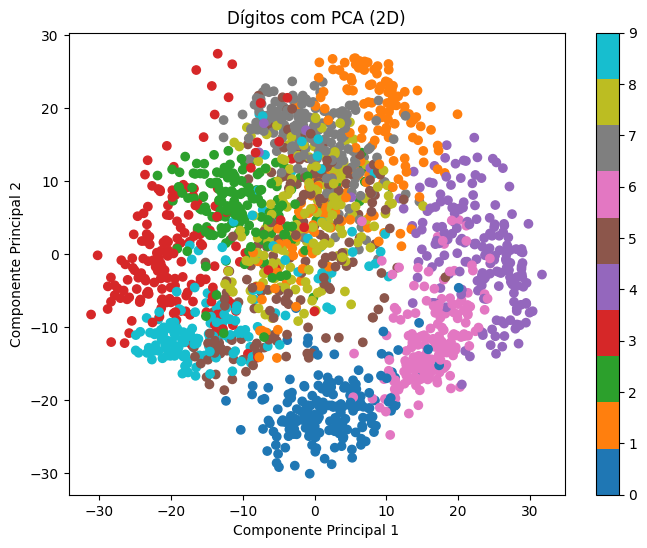

In [2]:
# =========================
# BLOCO 1 - IMPORTS
# =========================
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

# =========================
# BLOCO 2 - LOAD DATA
# =========================
digits = load_digits()
X = digits.data
y = digits.target

# =========================
# BLOCO 3 - PCA (2D)
# =========================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# =========================
# BLOCO 4 - PLOT
# =========================
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='tab10')
plt.colorbar(scatter)
plt.title("Dígitos com PCA (2D)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()

 Treino do Modelo

In [4]:
# =========================
# BLOCO 5 - SPLIT
# =========================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.33, random_state=42
)

# =========================
# BLOCO 6 - TREINO
# =========================
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# =========================
# BLOCO 7 - GUARDAR MODELO
# =========================
import joblib

joblib.dump(knn, "knn_digits_model.pkl")
joblib.dump((X_test, y_test), "test_data.pkl")

print("Modelo e dados guardados com sucesso!")

Modelo e dados guardados com sucesso!


Teste + Visualização

Acurácia: 0.63


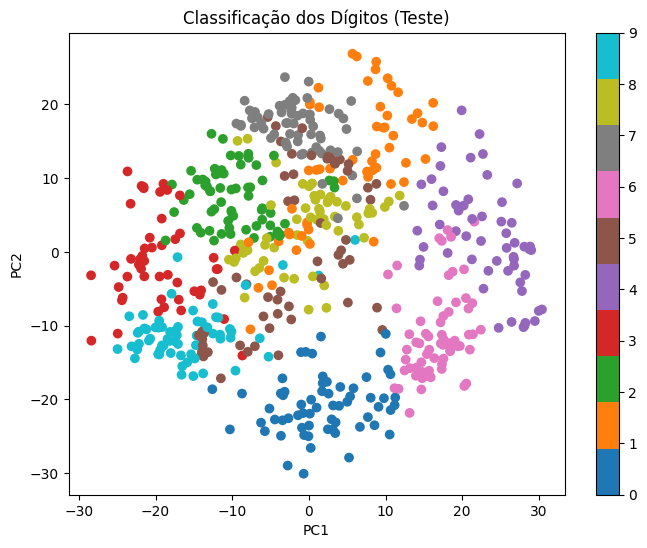

In [5]:
# =========================
# BLOCO 8 - LOAD
# =========================
knn = joblib.load("knn_digits_model.pkl")
X_test, y_test = joblib.load("test_data.pkl")

# =========================
# BLOCO 9 - PREDIÇÃO
# =========================
y_pred = knn.predict(X_test)

# =========================
# BLOCO 10 - ACCURACY
# =========================
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print(f"Acurácia: {acc:.2f}")

# =========================
# BLOCO 11 - PLOT RESULTADOS
# =========================
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_test[:,0], X_test[:,1], c=y_pred, cmap='tab10')
plt.colorbar(scatter)
plt.title("Classificação dos Dígitos (Teste)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Predição (novo exemplo)

Classe prevista: 0
Classe real: 0


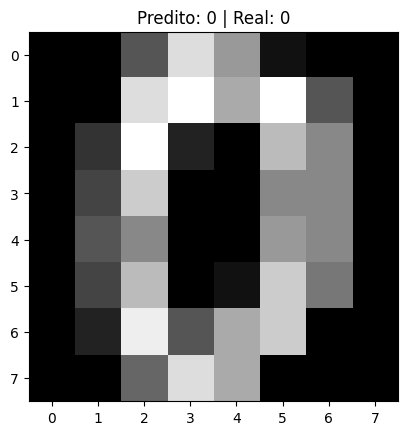

In [6]:
# =========================
# BLOCO 12 - NOVO EXEMPLO
# =========================

# Escolher um exemplo do dataset
novo_exemplo = X[0].reshape(1, -1)

# Aplicar PCA (mesmo modelo)
novo_exemplo_pca = pca.transform(novo_exemplo)

# Predição
pred = knn.predict(novo_exemplo_pca)

print("Classe prevista:", pred[0])
print("Classe real:", y[0])

# Mostrar imagem original
plt.imshow(digits.images[0], cmap='gray')
plt.title(f"Predito: {pred[0]} | Real: {y[0]}")
plt.show()